# Data Processing

In this notebook, we will prepare the dataset for modeling.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, RobustScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import os
from pandas.api import types as pd_types

# 🧹 Data Processing Overview

This notebook standardizes the entire data-processing workflow for both **Daily Data** and **Hourly Data**, ensuring clarity, consistency, and maintainability.

## 🎯 Objectives
- Clean and structure raw data using a unified logic.
- Handle missing values consistently across both datasets.
- Detect and cap outliers using the IQR method.
- Apply appropriate scaling (RobustScaler) for numeric features.
- Encode categorical features using OneHotEncoder.
- Export fully processed datasets ready for modeling.

## 🔧 Standardized Workflow
1. **Load Dataset**  
2. **Data Summary: Missing & Dtypes**  
3. **Drop columns with excessive missing values**  
4. **Identify numeric / categorical / datetime columns**  
5. **Outlier capping (IQR)**  
6. **Imputation (Iterative for numeric / most_frequent for categorical)**  
7. **Encoding & Scaling**  
8. **Save processed outputs**

This structure is applied consistently to both the daily and hourly datasets.


## DATA HANOI DAILY

**1. Overview of Data after Data Understanding**

In [2]:
# Load the dataset
df_daily = pd.read_excel(r'../../data/processed/data_daily_after_basic_understand.xlsx')

In [3]:
# Identify feature types
numerical_features = df_daily.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = df_daily.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numerical_features)
print("Categorical features:", categorical_features)

Numeric features: ['tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'moonphase']
Categorical features: ['conditions', 'description', 'icon', 'stations']


**2. Handling missing data**


In [4]:
# Check for missing values and duplicate rows
print("Number of missing values:\n", df_daily.isnull().sum())
print("\nPercentage of missing values (%):\n", (df_daily.isnull().mean() * 100).round(2))

dupes_daily = df_daily.duplicated().sum()
print(f"\nNumber of duplicate rows: {dupes_daily}")

Number of missing values:
 datetime               0
tempmax                0
tempmin                0
temp                   0
feelslikemax           0
feelslikemin           0
feelslike              0
dew                    0
humidity               0
precip                 0
precipprob             0
precipcover            0
windgust               0
windspeed              0
winddir                0
sealevelpressure       0
cloudcover             0
visibility             0
solarradiation         0
solarenergy            0
uvindex                0
severerisk          2566
sunrise                0
sunset                 0
moonphase              0
conditions             0
description            0
icon                   0
stations               0
dtype: int64

Percentage of missing values (%):
 datetime             0.00
tempmax              0.00
tempmin              0.00
temp                 0.00
feelslikemax         0.00
feelslikemin         0.00
feelslike            0.00
dew              

During the data exploration process, I observed that **only the `severerisk` column contains missing values**, with a **missing rate as high as 65.34%**. Such a high proportion of missing data suggests that the column provides limited informational value and may negatively impact model performance if retained. Furthermore, correlation analysis shows that `severerisk` has little to no relationship with the target variable. Keeping it would add noise rather than value to the model.  

Given the high missing rate, weak correlation, and lack of statistical reliability,  
the `severerisk` column will be **dropped** from the dataset prior to feature engineering and model training.

In [5]:
# Drop the 'severerisk' column
df_daily = df_daily.drop(columns=['severerisk'])

# Check the result
print("Data shape after dropping 'severerisk' column:", df_daily.shape)

Data shape after dropping 'severerisk' column: (3927, 28)


**3. Train-test split**

In [6]:
n = len(df_daily)
train_end = int(n * 0.721)
val_end = int(n * 0.8371)   # 70% + 15% = 85%

# 1. Train set: 0 → 70%
train_data = df_daily.iloc[:train_end]

# 2. Validation set: 70% → 85%
val_data = df_daily.iloc[train_end:val_end]

# 3. Test set: 85% → 100%
test_data = df_daily.iloc[val_end:]

print("Train set shape:", train_data.shape)
print("Validation set shape:", val_data.shape)
print("Test set shape:", test_data.shape)

print("\n=== Corresponding time periods ===")
print(f"Train: {train_data['datetime'].min()} → {train_data['datetime'].max()}")
print(f"Validation: {val_data['datetime'].min()} → {val_data['datetime'].max()}")
print(f"Test: {test_data['datetime'].min()} → {test_data['datetime'].max()}")

# Split into X and y
feature_cols = df_daily.columns.drop(['temp', 'datetime'])

X_train = train_data[feature_cols]
y_train = train_data['temp']

X_val = val_data[feature_cols]
y_val = val_data['temp']

X_test = test_data[feature_cols]
y_test = test_data['temp']

print(f"\nShapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Train set shape: (2831, 28)
Validation set shape: (456, 28)
Test set shape: (640, 28)

=== Corresponding time periods ===
Train: 2015-01-01 00:00:00 → 2022-10-01 00:00:00
Validation: 2022-10-02 00:00:00 → 2023-12-31 00:00:00
Test: 2024-01-01 00:00:00 → 2025-10-01 00:00:00

Shapes:
X_train: (2831, 26), y_train: (2831,)
X_val:   (456, 26), y_val:   (456,)
X_test:  (640, 26), y_test:  (640,)


Performing a chronological split of the daily weather dataset `df_daily` into training, validation, and test sets, and prepares the feature and target matrices for modeling:

1. **Determine dataset length and split indices**
   - `n = len(df_daily)` gets the total number of daily records.
   - `train_end` and `val_end` are computed as indices for approximately 72.1% (train) and 83.71% (validation) of the dataset, leaving the remaining ~16.3% for testing.

2. **Split the dataset**
   - `train_data`: first ~72% of records.
   - `val_data`: next ~12-13% of records (from 72% to 83.71%).
   - `test_data`: remaining records (~16% at the end).
   - Prints the shape and corresponding date ranges for each split to verify the temporal separation.

3. **Define feature columns**
   - `feature_cols` excludes `temp` (target) and `datetime` (time index).

4. **Prepare input (X) and output (y) datasets**
   - `X_train`, `X_val`, `X_test`: feature matrices for training, validation, and testing.
   - `y_train`, `y_val`, `y_test`: corresponding target values (temperature).
   - Prints the shapes of all feature and target arrays for confirmation.

This approach preserves **chronological order**, which is critical for time series modeling, ensuring no leakage of future information into the past.

**4. Observing and handling outliers**

In [7]:
# Identify numeric columns
numeric_cols_d = df_daily.select_dtypes(include=[np.number]).columns

# Compute Q1 and Q3 for each numeric column
Q1_d = df_daily[numeric_cols_d].quantile(0.25)
Q3_d = df_daily[numeric_cols_d].quantile(0.75)

# Compute IQR
IQR_d = Q3_d - Q1_d

# Detect outliers using the IQR rule: values < Q1 - 1.5*IQR or > Q3 + 1.5*IQR
outliers_d = ((df_daily[numeric_cols_d] < (Q1_d - 1.5 * IQR_d)) | 
              (df_daily[numeric_cols_d] > (Q3_d + 1.5 * IQR_d))).sum()

print("Number of outliers (per column):\n", outliers_d)

Number of outliers (per column):
 tempmax               3
tempmin               1
temp                  2
feelslikemax          0
feelslikemin         20
feelslike             0
dew                  41
humidity             91
precip              639
precipprob            0
precipcover         169
windgust            117
windspeed            59
winddir             664
sealevelpressure      1
cloudcover            0
visibility          119
solarradiation        0
solarenergy           0
uvindex               0
moonphase             0
dtype: int64


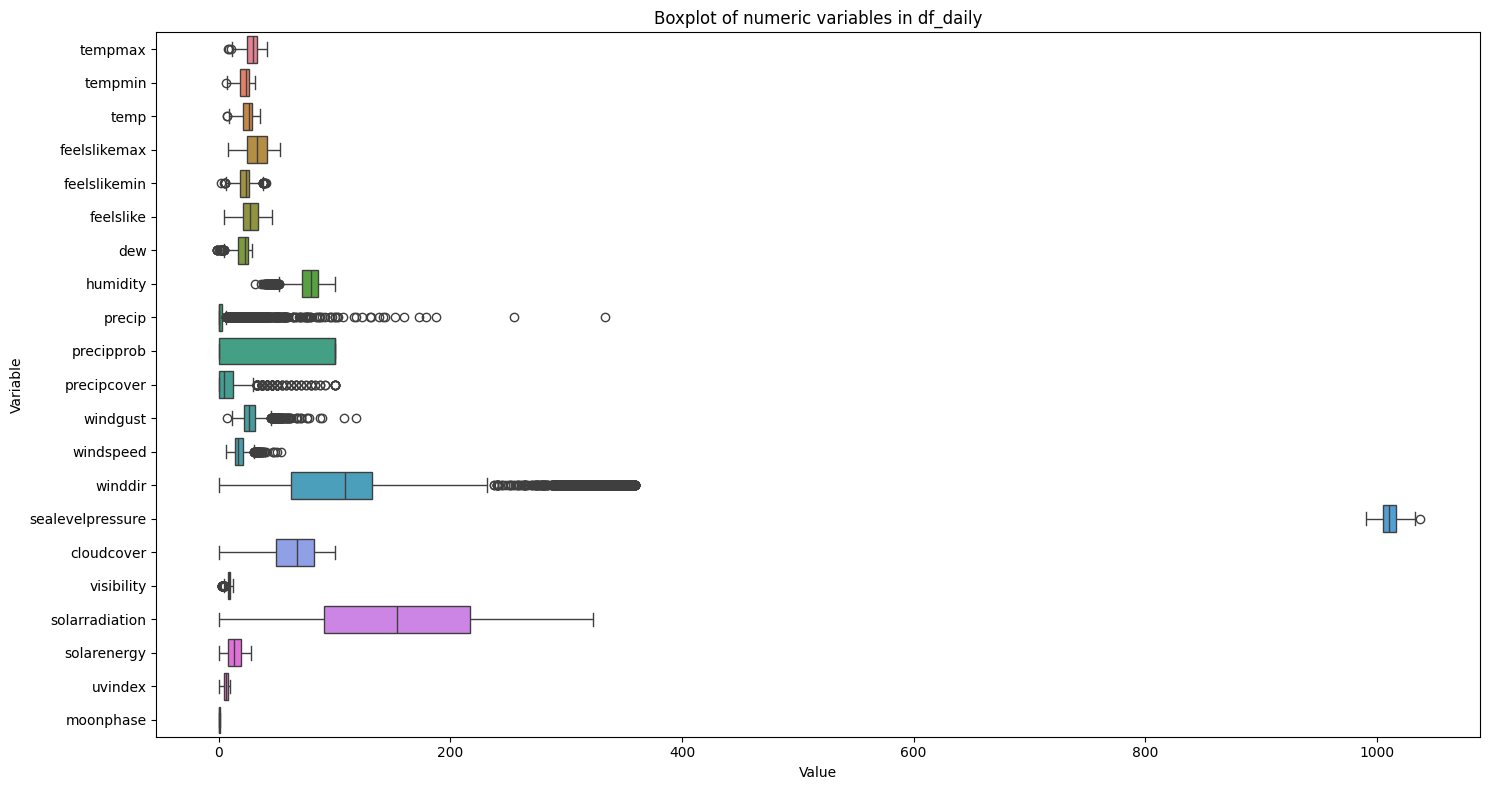

In [8]:
numeric_cols_d = df_daily.select_dtypes(include=['number']).columns

# Draw boxplot
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_daily[numeric_cols_d], orient='h', showfliers=True)
plt.title("Boxplot of numeric variables in df_daily")
plt.xlabel("Value")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [9]:
# Classify columns based on the number of outliers
def classify_columns_by_outliers(X, outlier_threshold=0.05):
    """
    Classify numeric columns into high-outlier and low-outlier columns
    outlier_threshold: threshold of outlier ratio for classification (default 5%)
    """
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    Q1 = X[numeric_cols].quantile(0.25)
    Q3 = X[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    
    outlier_counts = ((X[numeric_cols] < (Q1 - 1.5 * IQR)) | 
                      (X[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
    outlier_ratios = outlier_counts / len(X)
    
    high_outlier_cols = outlier_ratios[outlier_ratios > outlier_threshold].index.tolist()
    low_outlier_cols = outlier_ratios[outlier_ratios <= outlier_threshold].index.tolist()
    
    return high_outlier_cols, low_outlier_cols, outlier_ratios

# Classify columns for the daily dataset
high_outlier_cols, low_outlier_cols, outlier_ratios = classify_columns_by_outliers(X_train, outlier_threshold=0.05)

print("=== Column classification based on outliers ===")
print(f"\nColumns with many outliers (>5%): {high_outlier_cols}")
print(f"\nColumns with few outliers (<=5%): {low_outlier_cols}")
print(f"\nDetailed outlier ratios:\n{outlier_ratios.sort_values(ascending=False)}")

# Identify categorical columns
nominal_cols = X_train.select_dtypes(include=['object']).columns.tolist()
ordinal_cols = []  # If there are ordinal columns, declare them here

print(f"\nNominal columns: {nominal_cols}")
print(f"Ordinal columns: {ordinal_cols}")

=== Column classification based on outliers ===

Columns with many outliers (>5%): ['precip', 'winddir']

Columns with few outliers (<=5%): ['tempmax', 'tempmin', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity', 'precipprob', 'precipcover', 'windgust', 'windspeed', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'moonphase']

Detailed outlier ratios:
winddir             0.170964
precip              0.168492
precipcover         0.038502
windgust            0.029671
visibility          0.027552
humidity            0.021194
cloudcover          0.014836
windspeed           0.013070
dew                 0.010950
feelslikemin        0.006358
tempmax             0.001060
sealevelpressure    0.000706
tempmin             0.000353
feelslikemax        0.000000
precipprob          0.000000
feelslike           0.000000
solarradiation      0.000000
solarenergy         0.000000
uvindex             0.000000
moonphase           0.000000
dtype: f

In [10]:
# Separate datetime columns
datetime_cols = X_train.select_dtypes(include=['datetime']).columns.tolist()

# Separate non-datetime columns (numeric and categorical)
train_non_datetime = train_data.drop(columns=datetime_cols)
val_non_datetime = val_data.drop(columns=datetime_cols)
test_non_datetime = test_data.drop(columns=datetime_cols)

# Create a list of transformers
transformers = []

# OneHotEncoder for nominal columns
if nominal_cols:
    transformers.append(('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols))

# OrdinalEncoder for ordinal columns (if any)
if ordinal_cols:
    transformers.append(('ordinal', OrdinalEncoder(), ordinal_cols))

# Create ColumnTransformer (passthrough to keep columns that are not transformed)
preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder='passthrough', verbose_feature_names_out=False  # Keep original column names for passthrough
)

# ===== FIT AND TRANSFORM =====
print("\n=== Start fitting and transforming data ===")
train_transformed = preprocessor.fit_transform(train_non_datetime)
# Transform validation and test sets (use parameters learned from train)
val_transformed = preprocessor.transform(val_non_datetime)
test_transformed = preprocessor.transform(test_non_datetime)

print(f"\nShapes after transformation:")
print(f"  X_train: {train_non_datetime.shape} -> {train_transformed.shape}")
print(f"  X_val:   {val_non_datetime.shape} -> {val_transformed.shape}")
print(f"  X_test:  {test_non_datetime.shape} -> {test_transformed.shape}")

# Combine datetime columns back into the final result
# Ensure that datetime columns are unchanged
train_transformed = pd.DataFrame(train_transformed)
val_transformed = pd.DataFrame(val_transformed)
test_transformed = pd.DataFrame(test_transformed)

# Add datetime columns back
train_transformed[datetime_cols] = train_data[datetime_cols].reset_index(drop=True)
val_transformed[datetime_cols] = val_data[datetime_cols].reset_index(drop=True)
test_transformed[datetime_cols] = test_data[datetime_cols].reset_index(drop=True)

# Display results
print(f"  X_test: {test_transformed.shape}")

print(f"\nShapes after adding datetime columns back:")
print(f"  X_val:   {val_transformed.shape}")
print(f"  X_train: {train_transformed.shape}")



=== Start fitting and transforming data ===

Shapes after transformation:
  X_train: (2831, 26) -> (2831, 79)
  X_val:   (456, 26) -> (456, 79)
  X_test:  (640, 26) -> (640, 79)
  X_test: (640, 81)

Shapes after adding datetime columns back:
  X_val:   (456, 81)
  X_train: (2831, 81)


**Nominal columns** (nominal_cols) → **OneHotEncoder**:
- This is the standard way to handle discrete categorical text columns without any inherent order. OneHotEncoder creates a binary column for each unique value, allowing the model to understand the differences between categories without imposing any artificial order.

- Example: The conditions column has values ['Clear','Overcast', 'Partially cloudy', 'Rain', 'Rain, Overcast', 'Rain, Partially cloudy'] → it will create 6 columns: 'conditions_Clear', 'conditions_Overcast', 'conditions_Partially cloudy', 'conditions_Rain', 'conditions_Rain, Overcast', 'conditions_Rain, Partially cloudy', with values 0 or 1. The same applies to the columns in nominal_cols.

**Ordinal columns** (ordinal_cols) → **OrdinalEncoder**:
- Used for categorical columns with a natural order, where values indicate levels or ranks. OrdinalEncoder assigns an integer corresponding to the logical order of each value, helping the model recognize the increasing or decreasing relationship between categories.

In [11]:
# Fit the preprocessor on non-datetime data (if not already fitted)
preprocessor.fit(train_non_datetime)

# Transform train, validation, and test sets
train_arr = preprocessor.transform(train_non_datetime)
val_arr = preprocessor.transform(val_non_datetime)
test_arr = preprocessor.transform(test_non_datetime)

# Safely create feature names
try:
    # For sklearn >=1.0
    feature_names = list(preprocessor.get_feature_names_out(train_non_datetime.columns))
except Exception:
    feature_names = []
    used_cols = []
    for name, trans, cols in preprocessor.transformers_:
        if name == 'remainder':
            continue
        cols_list = list(cols) if isinstance(cols, (list, tuple, np.ndarray)) else [cols]
        used_cols.extend(cols_list)
        fitted = preprocessor.named_transformers_.get(name, None)
        if fitted is not None and hasattr(fitted, "get_feature_names_out"):
            try:
                out = fitted.get_feature_names_out(cols_list)
                feature_names.extend(list(out))
            except Exception:
                feature_names.extend([f"{name}__{c}" for c in cols_list])
        else:
            feature_names.extend([f"{name}__{c}" for c in cols_list])
    # Include passthrough columns if any
    if getattr(preprocessor, "remainder", None) == 'passthrough':
        passthrough = [c for c in train_non_datetime.columns if c not in used_cols]
        feature_names.extend(passthrough)

# Fallback in case of shape mismatch
if len(feature_names) != train_arr.shape[1]:
    feature_names = [f"feat_{i}" for i in range(train_arr.shape[1])]

# Convert arrays back to DataFrames, keeping original indices
train_transformed = pd.DataFrame(train_arr, columns=feature_names, index=train_non_datetime.index)
val_transformed = pd.DataFrame(val_arr, columns=feature_names, index=val_non_datetime.index)
test_transformed = pd.DataFrame(test_arr, columns=feature_names, index=test_non_datetime.index)

# Extract datetime columns from original data
datetime_cols = [c for c in train_data.columns if pd_types.is_datetime64_any_dtype(train_data[c])]

# Overwrite datetime columns in transformed DataFrames to preserve original values
for dt in datetime_cols:
    train_transformed[dt] = train_data.loc[train_transformed.index, dt].values
    val_transformed[dt] = val_data.loc[val_transformed.index, dt].values
    test_transformed[dt] = test_data.loc[test_transformed.index, dt].values

# Ensure column order: transformed features first, then datetime columns
final_feature_names = [c for c in feature_names if c not in datetime_cols] + datetime_cols
train_transformed = train_transformed[final_feature_names]
val_transformed = val_transformed[final_feature_names]
test_transformed = test_transformed[final_feature_names]

# Optionally add target 'temp' back for full dataset
train_data_transformed = train_transformed.copy()
train_data_transformed['temp'] = train_data.loc[train_transformed.index, 'temp'].values
val_data_transformed = val_transformed.copy()
val_data_transformed['temp'] = val_data.loc[val_transformed.index, 'temp'].values
test_data_transformed = test_transformed.copy()
test_data_transformed['temp'] = test_data.loc[test_transformed.index, 'temp'].values

# Features only (without target)
X_train_transformed = train_transformed.copy()
X_val_transformed = val_transformed.copy()
X_test_transformed = test_transformed.copy()

Handling **fitting a preprocessor**, transforming datasets, and preserving both feature names and datetime information for machine learning:

1. **Fit the preprocessor**
   - `preprocessor.fit(train_non_datetime)` fits the preprocessing pipeline only on non-datetime columns of the training set.

2. **Transform datasets**
   - `train_arr`, `val_arr`, `test_arr` are the transformed NumPy arrays for training, validation, and test sets.
   - Transformation is applied consistently across all sets to ensure matching feature representation.

3. **Safely extract feature names**
   - Tries `get_feature_names_out`.
   - If unavailable, iterates through transformers to construct feature names manually:
     - Handles columns created by transformers (e.g., one-hot encoding).
     - Includes passthrough columns if the preprocessor retains them.
   - Ensures fallback names (`feat_0`, `feat_1`, …) in case of mismatch between array and feature names.

4. **Convert arrays back to DataFrames**
   - Preserves original indices.
   - Ensures column names match the transformed features.

5. **Preserve original datetime columns**
   - Extracts datetime columns from the original data.
   - Overwrites these columns in the transformed DataFrames to retain original timestamps.

6. **Ensure consistent column order**
   - Features first, then datetime columns, creating `final_feature_names`.

7. **Optionally add target back**
   - Adds `temp` column to the transformed DataFrames for a complete dataset (`train_data_transformed`, etc.).

8. **Prepare feature-only DataFrames**
   - `X_train_transformed`, `X_val_transformed`, `X_test_transformed` contain only features without the target, ready for model input.

**Key benefits of this approach:**
- Maintains proper **feature names** after complex transformations.
- Keeps **datetime information intact** for time series analysis.
- Ensures **train-validation-test consistency** for downstream modeling.

In [12]:
feature_cols = train_transformed.columns.drop(['temp', 'datetime']) 
X_train_transformed = train_transformed[feature_cols]
y_train_transformed = train_transformed['temp']
X_val_transformed = val_transformed[feature_cols]
y_val_transformed = val_transformed['temp']
X_test_transformed = test_transformed[feature_cols]
y_test_transformed = test_transformed['temp']

In [13]:
save_dir = '../../data/processed/'
os.makedirs(save_dir, exist_ok=True)  # Ensure the directory exists

# Save full datasets (including target)
train_data_transformed.to_excel(os.path.join(save_dir, 'train_data.xlsx'), index=False)
val_data_transformed.to_excel(os.path.join(save_dir, 'val_data.xlsx'), index=False)
test_data_transformed.to_excel(os.path.join(save_dir, 'test_data.xlsx'), index=False)

# Save features (X) and targets (y) separately
X_train_transformed.to_excel(os.path.join(save_dir, 'X_train.xlsx'), index=False)
y_train_transformed.to_excel(os.path.join(save_dir, 'y_train.xlsx'), index=False)

X_val_transformed.to_excel(os.path.join(save_dir, 'X_val.xlsx'), index=False)
y_val_transformed.to_excel(os.path.join(save_dir, 'y_val.xlsx'), index=False)

X_test_transformed.to_excel(os.path.join(save_dir, 'X_test.xlsx'), index=False)
y_test_transformed.to_excel(os.path.join(save_dir, 'y_test.xlsx'), index=False)

# --- Confirmation ---
print(f"\n💾 Saved 9 Daily files to: {save_dir}")
print(f"  - train_data.xlsx (shape: {train_data_transformed.shape})")
print(f"  - val_data.xlsx (shape: {val_data_transformed.shape})")
print(f"  - test_data.xlsx (shape: {test_data_transformed.shape})")
print(f"  - X_train.xlsx, y_train.xlsx")
print(f"  - X_val.xlsx, y_val.xlsx")
print(f"  - X_test.xlsx, y_test.xlsx")


💾 Saved 9 Daily files to: ../../data/processed/
  - train_data.xlsx (shape: (2831, 81))
  - val_data.xlsx (shape: (456, 81))
  - test_data.xlsx (shape: (640, 81))
  - X_train.xlsx, y_train.xlsx
  - X_val.xlsx, y_val.xlsx
  - X_test.xlsx, y_test.xlsx


In [14]:
print(train_transformed.dtypes)

conditions_Clear                       object
conditions_Overcast                    object
conditions_Partially cloudy            object
conditions_Rain                        object
conditions_Rain, Overcast              object
                                    ...      
uvindex                                object
moonphase                              object
datetime                       datetime64[ns]
sunrise                        datetime64[ns]
sunset                         datetime64[ns]
Length: 81, dtype: object


In [15]:
print(X_train.dtypes)

tempmax                    float64
tempmin                    float64
feelslikemax               float64
feelslikemin               float64
feelslike                  float64
dew                        float64
humidity                   float64
precip                     float64
precipprob                   int64
precipcover                float64
windgust                   float64
windspeed                  float64
winddir                    float64
sealevelpressure           float64
cloudcover                 float64
visibility                 float64
solarradiation             float64
solarenergy                float64
uvindex                      int64
sunrise             datetime64[ns]
sunset              datetime64[ns]
moonphase                  float64
conditions                  object
description                 object
icon                        object
stations                    object
dtype: object


In [16]:
# Compute correlation matrix for numeric columns only
corr = df_daily.corr(numeric_only=True)

# Print the correlation matrix
print(corr)

                   tempmax   tempmin      temp  feelslikemax  feelslikemin  \
tempmax           1.000000  0.909259  0.977722      0.964647      0.889029   
tempmin           0.909259  1.000000  0.969581      0.910259      0.963060   
temp              0.977722  0.969581  1.000000      0.957785      0.942461   
feelslikemax      0.964647  0.910259  0.957785      1.000000      0.899939   
feelslikemin      0.889029  0.963060  0.942461      0.899939      1.000000   
feelslike         0.954692  0.942145  0.974478      0.979062      0.951898   
dew               0.843814  0.932995  0.902911      0.866739      0.872035   
humidity          0.011194  0.226346  0.100473      0.097697      0.140572   
precip            0.056500  0.130930  0.090129      0.099973      0.079126   
precipprob        0.069758  0.251155  0.150019      0.141172      0.186441   
precipcover       0.061395  0.170696  0.106710      0.094612      0.124118   
windgust          0.126321  0.144815  0.135714      0.119640    

**Correlation Analysis**

- **Temperature (`tempmax`, `tempmin`, `temp`, `feelslikemax`, `feelslikemin`, `feelslike`)**  
  - Highly correlated (0.88 – 0.98) → redundant, consider feature selection or dimensionality reduction.

- **Dew Point (`dew`)**  
  - Correlated with temperature (0.84 – 0.90) → physically consistent.

- **Sea Level Pressure (`sealevelpressure`)**  
  - Strong negative correlation with temperature (-0.83 – -0.88).

- **Cloud Cover & Visibility (`cloudcover`, `visibility`)**  
  - Moderate correlations with temperature/pressure → show cloudiness and visibility effects.

- **Solar Variables (`solarradiation`, `solarenergy`, `uvindex`)**  
  - Highly correlated (>0.96) and moderately with temperature (~0.62 – 0.67) → same underlying factor: solar radiation.

- **Humidity & Precipitation (`humidity`, `precip`, `precipprob`, `precipcover`)**  
  - Weak to moderate correlations (0.13 – 0.53) → provide distinct moisture info.

- **Wind (`windgust`, `windspeed`, `winddir`)**  
  - Moderate correlations among themselves, low with temperature → relatively independent.

- **Moon Phase (`moonphase`)**  
  - Almost uncorrelated (~0) → independent, optional feature.

---

**Summary:**  
- Temp & solar variables → highly correlated, may reduce features.  
- Humidity, precipitation, wind → low/moderate correlation, keep for diversity.  
- Moon phase → independent, optional.
